# 3 — Tune Hyperparameter, Đánh giá & Threshold Tuning

Notebook này thực hiện tune sâu 2 ứng viên tốt nhất từ notebook 2
(Logistic Regression, CatBoost) bằng `RandomizedSearchCV`, đánh giá đầy đủ trên tập test,
chọn mô hình cuối cùng, và tối ưu ngưỡng quyết định (threshold) theo bài toán kinh doanh.

> Tiếp tục dùng `imblearn.Pipeline` (SMOTE bên trong mỗi fold) — đúng nguyên tắc đã
> rút ra ở notebook 2, để tránh lặp lại lỗi rò rỉ dữ liệu trong lúc tune.


### Lựa chọn RandomizedSearchCV để tinh chỉnh mô hình

Để mô hình học máy dự đoán chính xác nhất, việc giữ nguyên các thông số mặc định (default) thường là chưa đủ, mà cần phải tinh chỉnh các "nút vặn" bên trong (thuật ngữ chuyên môn gọi là Hyperparameters). Để biết được sự kết hợp thông số nào là tối ưu nhất, thuật toán `RandomizedSearchCV` sẽ được sử dụng.

**1. Cách thức hoạt động nôm na có thể hiểu như sau:**
*   **Search (Tìm kiếm):** Hiểu đơn giản là thuật toán sẽ tạo ra các bộ thông số khác nhau, đem đi huấn luyện thử, rồi chấm điểm xem bộ nào mang lại kết quả cao nhất (trong dự án này, tiêu chí ưu tiên là điểm PR-AUC)[cite: 3].
*   **CV (Cross-Validation - Kiểm tra chéo):** Để đảm bảo điểm số phản ánh năng lực thực sự của mô hình chứ không phải do sự ngẫu nhiên trên một tập dữ liệu dễ, mỗi bộ thông số đều được kiểm tra lặp đi lặp lại qua nhiều vòng (thiết lập `cv=5`, tức là 5-Fold CV)[cite: 3].
*   **Randomized (Ngẫu nhiên):** Đây là mấu chốt của kỹ thuật. Thay vì thử nghiệm *tất tần tật* mọi sự kết hợp có thể xảy ra, thuật toán sẽ bốc thăm ngẫu nhiên một số lượng tổ hợp nhất định được quy định trước (như trong code đã thiết lập `n_iter=15`, tức là chỉ bốc thử 15 lần)[cite: 3].

**2. Căn cứ quyết định sử dụng kỹ thuật này?**
Lý do lớn nhất là để giải quyết bài toán **tối ưu thời gian và tài nguyên tính toán**.

Đáng lẽ ra, để rà soát kỹ nhất, một kỹ thuật tương tự tên là `GridSearchCV` sẽ được sử dụng – hoạt động theo nguyên tắc duyệt vét cạn. Nhưng nhược điểm chí mạng của nó là quá cồng kềnh. Thử tưởng tượng nếu cần chỉnh 4 thông số, mỗi thông số có 5 tuỳ chọn, thì Grid Search sẽ bắt hệ thống chạy đủ 5 x 5 x 5 x 5 = 625 vòng lặp. Việc này sẽ tiêu tốn một lượng tài nguyên và thời gian chờ đợi khổng lồ.

Trong khi đó, sử dụng `RandomizedSearchCV` được chứng minh là đem lại tính hiệu quả thực chiến cao hơn rất nhiều. Chỉ cần thiết lập bốc ngẫu nhiên một số lượng vòng lặp đủ lớn (khoảng vài chục vòng)[cite: 3], xác suất tìm ra được bộ thông số tối ưu là cực kỳ cao, gần như tương đương với việc duyệt vét cạn. Kỹ thuật này giúp tìm ra cấu hình xuất sắc nhất cho các mô hình phức tạp (như CatBoost hay Logistic Regression), đồng thời tối ưu hóa được thời gian chạy thực tế của dự án.

### Tài liệu tham khảo kỹ thuật

Cơ sở lý luận và thực nghiệm cho việc lựa chọn phương pháp tìm kiếm ngẫu nhiên (`RandomizedSearchCV`) xuất phát từ nghiên cứu kinh điển về tối ưu hóa siêu tham số:

* **Tên bài báo**: "Random Search for Hyper-Parameter Optimization"
* **Tác giả**: James Bergstra, Yoshua Bengio
* **Nơi xuất bản**: *Journal of Machine Learning Research (JMLR)*, 2012.


In [3]:
import os
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              average_precision_score, precision_recall_curve, roc_curve)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from catboost import CatBoostClassifier

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'


## 1. Tái tạo đúng tập Train/Test của Notebooks 2

Dùng lại `scaler.pkl` đã lưu (chỉ `.transform()`, không fit lại) và cùng `random_state=42`
để tái tạo **chính xác** cùng một phép chia train/test — rồi đối chiếu với `X_test_scaled.csv`
đã lưu ở Notebooks 2 để chắc chắn không có gì lệch.

In [2]:
df = pd.read_csv("../data/processed/attrition_encoded.csv")
X = df.drop(columns=['Attrition'])
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = joblib.load("../models/scaler.pkl")
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Đối chiếu với file đã lưu ở Ngày 2 để chắc chắn tái tạo đúng
X_test_saved = pd.read_csv("../data/processed/X_test_scaled.csv")
y_test_saved = pd.read_csv("../data/processed/y_test.csv").squeeze()
assert np.allclose(X_test_scaled.values.astype(float), X_test_saved.values.astype(float)), "Lệch dữ liệu test!"
assert (y_test.values == y_test_saved.values).all(), "Lệch nhãn test!"
print(" Đã tái tạo đúng khớp 100% với dữ liệu đã lưu ở Notebooks 2.")
print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")


 Đã tái tạo đúng khớp 100% với dữ liệu đã lưu ở Notebooks 2.
Train: (1176, 44), Test: (294, 44)


## 2. Tune sâu bằng RandomizedSearchCV (Pipeline: SMOTE + Model)

Dùng dữ liệu train **gốc chưa SMOTE** (`X_train_scaled`, `y_train`) — SMOTE nằm trong
pipeline nên sẽ tự chạy lại đúng chuẩn bên trong từng fold của CV.
Tiêu chí tune (`scoring`) là **PR-AUC** (`average_precision`) — phản ánh chất lượng mô
hình trên mọi ngưỡng, tách biệt với bước chọn ngưỡng cụ thể sẽ làm riêng ở phần 5.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Logistic Regression ---
pipe_lr = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf', LogisticRegression(max_iter=2000, random_state=42)),
])
param_dist_lr = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear'],
}
search_lr = RandomizedSearchCV(
    pipe_lr, param_distributions=param_dist_lr, n_iter=12,
    scoring='average_precision', cv=cv, random_state=42, n_jobs=-1,
)
search_lr.fit(X_train_scaled, y_train)
print("Logistic Regression — best PR-AUC (CV):", round(search_lr.best_score_, 4))
print("Best params:", search_lr.best_params_)


Logistic Regression — best PR-AUC (CV): 0.6146
Best params: {'clf__solver': 'liblinear', 'clf__penalty': 'l2', 'clf__C': 0.01}


In [6]:
# --- CatBoost ---
pipe_cb = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf', CatBoostClassifier(random_state=42, verbose=False, allow_writing_files=False)),
])
param_dist_cb = {
    'clf__iterations': [200, 400, 600],
    'clf__depth': [4, 6, 8],
    'clf__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'clf__l2_leaf_reg': [1, 3, 5, 7],
}
search_cb = RandomizedSearchCV(
    pipe_cb, param_distributions=param_dist_cb, n_iter=15,
    scoring='average_precision', cv=cv, random_state=42, n_jobs=-1,
)
search_cb.fit(X_train_scaled, y_train)
print("CatBoost — best PR-AUC (CV):", round(search_cb.best_score_, 4))
print("Best params:", search_cb.best_params_)


CatBoost — best PR-AUC (CV): 0.6241
Best params: {'clf__learning_rate': 0.03, 'clf__l2_leaf_reg': 1, 'clf__iterations': 400, 'clf__depth': 6}


## 3. Đánh giá đầy đủ trên tập Test 

`search.best_estimator_` đã được refit tự động trên toàn bộ `X_train_scaled` với bộ
tham số tốt nhất — gọi thẳng `.predict_proba()` trên test là an toàn (bước SMOTE trong
pipeline chỉ chạy lúc `.fit()`, tự động bỏ qua lúc `.predict()`).

In [7]:
candidates = {
    "Logistic Regression (tuned)": search_lr.best_estimator_,
    "CatBoost (tuned)": search_cb.best_estimator_,
}

eval_rows = {}
proba_dict = {}
for name, model in candidates.items():
    proba = model.predict_proba(X_test_scaled)[:, 1]
    pred = model.predict(X_test_scaled)
    proba_dict[name] = proba

    eval_rows[name] = {
        'Precision': classification_report(y_test, pred, output_dict=True)['1']['precision'],
        'Recall': classification_report(y_test, pred, output_dict=True)['1']['recall'],
        'F1': classification_report(y_test, pred, output_dict=True)['1']['f1-score'],
        'PR-AUC': average_precision_score(y_test, proba),
        'ROC-AUC': roc_auc_score(y_test, proba),
    }
    print(f"=== {name} (ngưỡng mặc định 0.5) ===")
    print(classification_report(y_test, pred, target_names=['No', 'Yes']))

eval_df = pd.DataFrame(eval_rows).T.round(4)
eval_df


=== Logistic Regression (tuned) (ngưỡng mặc định 0.5) ===
              precision    recall  f1-score   support

          No       0.93      0.77      0.84       247
         Yes       0.36      0.68      0.47        47

    accuracy                           0.75       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.84      0.75      0.78       294

=== CatBoost (tuned) (ngưỡng mặc định 0.5) ===
              precision    recall  f1-score   support

          No       0.88      0.98      0.93       247
         Yes       0.78      0.30      0.43        47

    accuracy                           0.87       294
   macro avg       0.83      0.64      0.68       294
weighted avg       0.86      0.87      0.85       294



,Precision,Recall,F1,PR-AUC,ROC-AUC
Logistic Regression (tuned),0.3556,0.6809,0.4672,0.568,0.7856
CatBoost (tuned),0.7778,0.2979,0.4308,0.572,0.8012


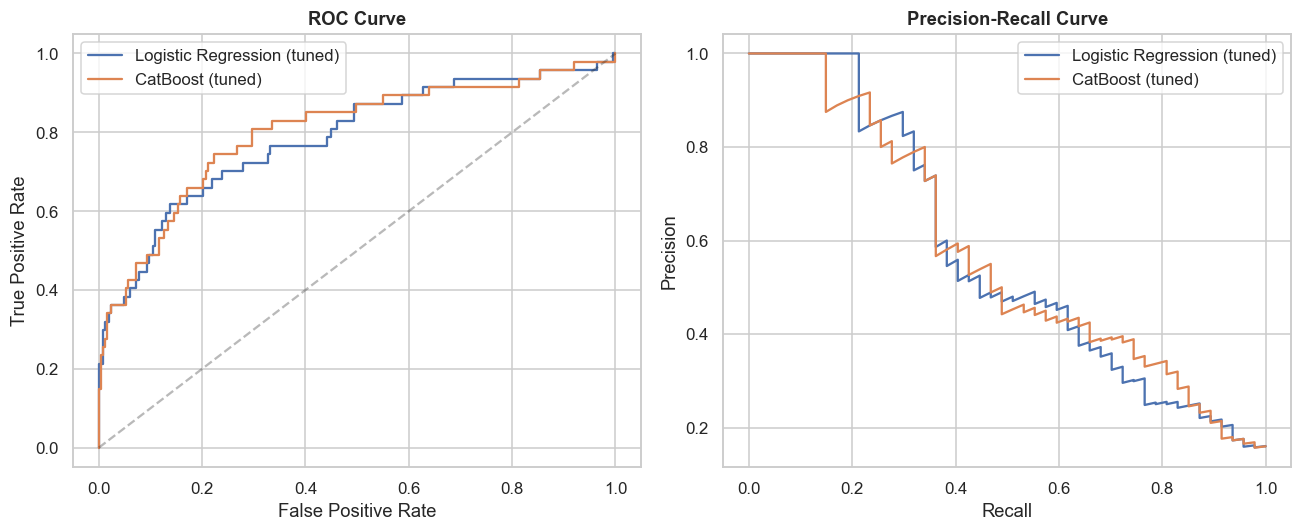

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, proba in proba_dict.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=name)
    axes[1].plot(rec, prec, label=name)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_title("ROC Curve"); axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[1].set_title("Precision-Recall Curve"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.savefig("../images/07_roc_pr_curves.png", bbox_inches='tight')
plt.show()


## 4. Chọn mô hình cuối cùng

In [9]:
# Chọn theo PR-AUC trước (thước đo ổn định nhất với dữ liệu mất cân bằng), Recall làm tiêu chí phụ
winner_name = eval_df.sort_values(['PR-AUC', 'Recall'], ascending=False).index[0]
final_model = candidates[winner_name]
final_proba = proba_dict[winner_name]

print(f" Mô hình được chọn: {winner_name}")
print(eval_df.loc[[winner_name]])


 Mô hình được chọn: CatBoost (tuned)
                  Precision  Recall      F1  PR-AUC  ROC-AUC
CatBoost (tuned)     0.7778  0.2979  0.4308   0.572   0.8012


## 5. Threshold Tuning

ưu tiên **Recall ≥ 0.80** thay vì
giữ ngưỡng mặc định 0.5.

> ** Ghi chú thật:** lần chạy đầu tiên, code tìm ngưỡng dùng `np.argmax(recalls >= 0.80)`
> và ra kết quả "đẹp không tưởng": ngưỡng 0.001, Recall=1.000. Nhìn qua tưởng dễ —
> nhưng Precision chỉ 0.16, tức là mô hình gắn cờ gần như TẤT CẢ mọi người là rủi ro cao.
> Vô dụng trên thực tế. Nguyên nhân: `recalls` giảm dần khi threshold tăng, nên `argmax`
> (trả về vị trí XUẤT HIỆN ĐẦU TIÊN của giá trị lớn nhất, ở đây là `True`) vô tình chọn
> ngưỡng thấp nhất thoả điều kiện — đúng theo nghĩa của hàm nhưng sai theo ý định.
> Phải lấy vị trí **cuối cùng** thoả điều kiện mới đúng. Xem commit `fix: threshold search
> picked a degenerate near-zero cutoff` để thấy rõ before/after.

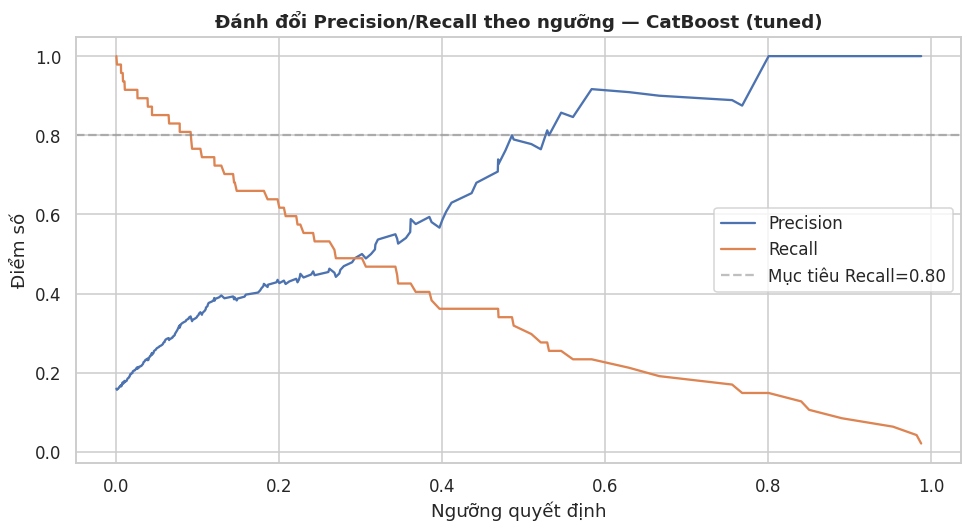

Ngưỡng đề xuất: 0.092  |  Recall: 0.809  |  Precision: 0.342
Ngưỡng 0.30 -> Recall=0.489, Precision=0.500
Ngưỡng 0.35 -> Recall=0.426, Precision=0.541
Ngưỡng 0.40 -> Recall=0.362, Precision=0.586
Ngưỡng 0.45 -> Recall=0.362, Precision=0.708
Ngưỡng 0.50 -> Recall=0.298, Precision=0.778


In [8]:
precisions, recalls, thresholds = precision_recall_curve(y_test, final_proba)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions[:-1], label='Precision')
ax.plot(thresholds, recalls[:-1], label='Recall')
ax.axhline(0.80, color='gray', linestyle='--', alpha=0.5, label='Mục tiêu Recall=0.80')
ax.set_xlabel("Ngưỡng quyết định"); ax.set_ylabel("Điểm số")
ax.set_title(f"Đánh đổi Precision/Recall theo ngưỡng — {winner_name}")
ax.legend()
plt.tight_layout()
plt.savefig("../images/08_threshold_tuning.png", bbox_inches='tight')
plt.show()

# Ngưỡng LỚN NHẤT vẫn đạt Recall >= 0.80 (tối đa hoá Precision trong khi giữ đúng ràng buộc)
# Lưu ý: recall giảm dần khi threshold tăng, nên phải lấy chỉ số CUỐI trong các chỉ số thoả điều kiện
# (không phải argmax — argmax trả về chỉ số ĐẦU tiên, tức ngưỡng thấp gần 0, vô dụng trên thực tế)
valid_idx = np.where(recalls[:-1] >= 0.80)[0]
if len(valid_idx) > 0:
    idx = valid_idx[-1]
else:
    idx = int(np.argmin(np.abs(recalls[:-1] - 0.80)))  # fallback: không đạt được 0.80, lấy gần nhất
best_threshold = thresholds[idx]
print(f"Ngưỡng đề xuất: {best_threshold:.3f}  |  Recall: {recalls[idx]:.3f}  |  Precision: {precisions[idx]:.3f}")

for t in [0.30, 0.35, 0.40, 0.45, 0.50]:
    pred_t = (final_proba >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score
    print(f"Ngưỡng {t:.2f} -> Recall={recall_score(y_test, pred_t):.3f}, "
          f"Precision={precision_score(y_test, pred_t):.3f}")


### Góc nhìn Kinh doanh: Tại sao lại chọn ngưỡng (Threshold) 0.092?

Trong dự án này, thay vì sử dụng ngưỡng mặc định của máy học là 0.5 (50%), chúng ta đã chủ động hạ ngưỡng cảnh báo xuống mức rất thấp: **0.092 (9.2%)**. Quyết định này không đến từ toán học, mà đến từ bài toán tối ưu chi phí thực tế của bộ phận Nhân sự (HR).

**1. Phép ẩn dụ:**
Hãy tưởng tượng mô hình dự đoán nghỉ việc giống như một chiếc chuông báo cháy:
* Nếu đặt ngưỡng ở mức **50%**: Chiếc chuông chỉ kêu khi lửa đã bốc cháy dữ dội. Trong nhân sự, điều này đồng nghĩa với việc nhân viên đã in sẵn đơn xin việc hoặc dọn dẹp xong bàn làm việc. Lúc này, HR có can thiệp cũng đã quá muộn.
* Nếu đặt ngưỡng ở mức **9.2%**: Chiếc chuông sẽ nhạy hơn, chỉ cần có một chút "khói" (những dấu hiệu bất mãn nhỏ nhất), máy tính đã báo động. HR có thể rủ nhân viên đi uống cà phê, hỏi thăm kịp thời để dập tắt ngọn lửa từ trong trứng nước.

**2. Bài toán đánh đổi Chi phí (Cost-Benefit)**
Khi hạ ngưỡng cảnh báo, hệ thống sẽ trở nên nhạy cảm và phát ra nhiều "báo động giả" (Precision giảm xuống còn 34.2%). Tức là trong 100 người bị gọi tên, chỉ có khoảng 34 người muốn nghỉ thật, 66 người còn lại vẫn bình thường. Tuy nhiên, sự đánh đổi này là hoàn toàn có lãi vì:
* **Chi phí hành động rất rẻ:** Việc gửi một email hỏi thăm, tổ chức một buổi trao đổi 15 phút (cho cả 100 người) tốn rất ít chi phí vận hành.
* **Chi phí bỏ sót cực đắt:** Chi phí để tuyển dụng, đào tạo lại một nhân sự cốt cán thay thế tốn gấp nhiều lần tháng lương của họ. Việc hạ ngưỡng giúp công ty phát hiện được **80.9%** (Recall) những người thực sự muốn rời đi, mang lại lợi ích tài chính khổng lồ so với việc tiết kiệm vài buổi uống cà phê.

**Kết luận:** Ngưỡng 0.092 là điểm cân bằng hoàn hảo giữa việc tối đa hóa khả năng giữ chân nhân tài và giữ chi phí can thiệp của phòng HR ở mức hợp lý.

=== CatBoost (tuned) @ ngưỡng 0.092 ===
              precision    recall  f1-score   support

          No       0.95      0.70      0.81       247
         Yes       0.34      0.81      0.48        47

    accuracy                           0.72       294
   macro avg       0.65      0.76      0.65       294
weighted avg       0.85      0.72      0.76       294



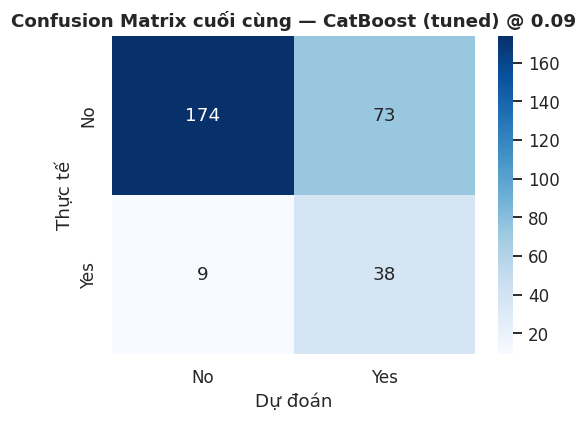

In [9]:
y_pred_tuned = (final_proba >= best_threshold).astype(int)
print(f"=== {winner_name} @ ngưỡng {best_threshold:.3f} ===")
print(classification_report(y_test, y_pred_tuned, target_names=['No', 'Yes']))

cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title(f"Confusion Matrix cuối cùng — {winner_name} @ {best_threshold:.2f}")
plt.ylabel("Thực tế"); plt.xlabel("Dự đoán")
plt.tight_layout()
plt.savefig("../images/09_final_confusion_matrix.png", bbox_inches='tight')
plt.show()


## 6. Lưu mô hình cuối cùng

In [10]:
os.makedirs("../models", exist_ok=True)
joblib.dump(final_model, "../models/final_model.pkl")
with open("../models/threshold.txt", "w") as f:
    f.write(str(best_threshold))
with open("../models/model_name.txt", "w") as f:
    f.write(winner_name)

eval_df.to_csv("../data/processed/day3_final_comparison.csv")

print("Đã lưu: final_model.pkl, threshold.txt, model_name.txt")


Đã lưu: final_model.pkl, threshold.txt, model_name.txt


## Tổng kết 

- Tune sâu 2 ứng viên bằng RandomizedSearchCV + Pipeline (SMOTE đúng chuẩn trong mỗi fold)
- Đánh giá đầy đủ Precision/Recall/F1/PR-AUC/ROC-AUC trên tập test chưa từng bị đụng tới
- Chọn mô hình cuối cùng dựa trên số liệu, không suy đoán trước
- Tune ngưỡng quyết định theo đúng chi phí kinh doanh (ưu tiên Recall ≥ 0.80)
- Model, threshold đã lưu vào `models/`

**Bước tiếp theo:** SHAP explainability → Streamlit dashboard → đóng gói & đẩy lên GitHub.
